You are given an m x n integer matrix grid​​​, where m and n are both even integers, and an integer k.

The matrix is composed of several layers, which is shown in the below image, where each color is its own layer:

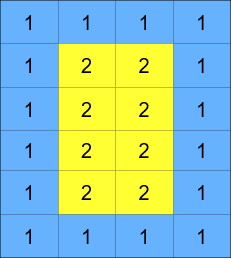

A cyclic rotation of the matrix is done by cyclically rotating each layer in the matrix. To cyclically rotate a layer once, each element in the layer will take the place of the adjacent element in the counter-clockwise direction. An example rotation is shown below:

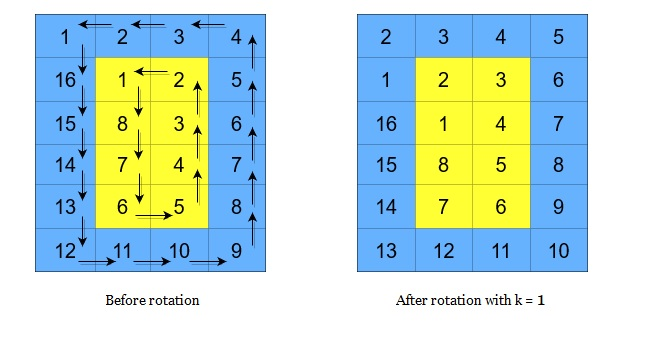

Return the matrix after applying k cyclic rotations to it.

 

Example 1:

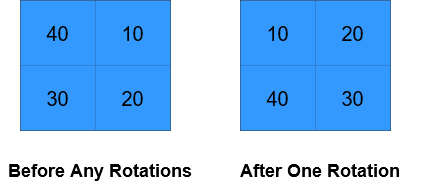

Input: grid = [[40,10],[30,20]], k = 1
Output: [[10,20],[40,30]]
Explanation: The figures above represent the grid at every state.

Example 2:

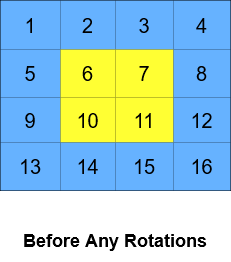

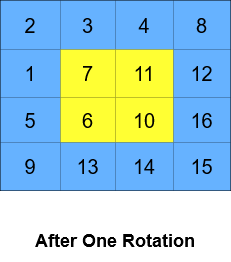

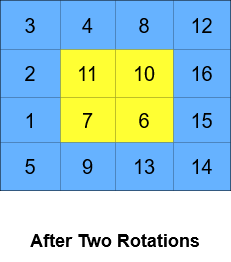

Input: grid = [[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]], k = 2
Output: [[3,4,8,12],[2,11,10,16],[1,7,6,15],[5,9,13,14]]
Explanation: The figures above represent the grid at every state.

 

Constraints:

    m == grid.length
    n == grid[i].length
    2 <= m, n <= 50
    Both m and n are even integers.
    1 <= grid[i][j] <= 5000
    1 <= k <= 109


In [ ]:
class Solution:
    def rotateGrid(self, grid: List[List[int]], k: int) -> List[List[int]]:
        m, n = len(grid), len(grid[0])
        nlayer = min(m // 2, n // 2)  # level count
        # enumerate each layer counterclockwise starting from the top-left corner
        for layer in range(nlayer):
            r = []  # row index of each element
            c = []  # column index of each element
            val = []  # value of each element
            for i in range(layer, m - layer - 1):  # left
                r.append(i)
                c.append(layer)
                val.append(grid[i][layer])
            for j in range(layer, n - layer - 1):  # down
                r.append(m - layer - 1)
                c.append(j)
                val.append(grid[m - layer - 1][j])
            for i in range(m - layer - 1, layer, -1):  # right
                r.append(i)
                c.append(n - layer - 1)
                val.append(grid[i][n - layer - 1])
            for j in range(n - layer - 1, layer, -1):  # up
                r.append(layer)
                c.append(j)
                val.append(grid[layer][j])
            total = len(val)  # total number of elements in each layer
            kk = k % total  # equivalent number of rotations
            # find the value at each index after rotation
            for i in range(total):
                idx = (
                    i + total - kk
                ) % total  # the index corresponding to the value after rotation
                grid[r[i]][c[i]] = val[idx]
        return grid